# Garment category classification using FashionClip pretrained model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import joblib

In [2]:
DATA_PATH = "../data/processed/polyvore_fashionclip_features.parquet"
df = pd.read_parquet(DATA_PATH)

X = np.vstack(df['embedding'].values) 
label_encoder = joblib.load("../models/label_encoder.pkl")
y = label_encoder.transform(df['category'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Temp data equally into 10% Validation and 10% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train shapes - X: {X_train.shape}, y: {y_train.shape}")
print(f"Valid shapes - X: {X_val.shape}, y: {y_val.shape}")
print(f"Test shapes  - X: {X_test.shape}, y: {y_test.shape}")

Train shapes - X: (200806, 512), y: (200806,)
Valid shapes - X: (25101, 512), y: (25101,)
Test shapes  - X: (25101, 512), y: (25101,)


## Model

In [3]:
class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EmbeddingDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader = DataLoader(EmbeddingDataset(X_val, y_val), batch_size=256, shuffle=False)
test_loader = DataLoader(EmbeddingDataset(X_test, y_test), batch_size=256, shuffle=False)

In [4]:
model = nn.Sequential(
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 11)
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

## Train

In [5]:
EPOCHS = 25
train_loss = []
val_loss = []
best_val_loss = float('inf')

print(f"Starting training on {device.upper()}...")
for epoch in range(EPOCHS):
    model.train()
    total_train_loss, train_correct = 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        
    train_acc = train_correct / len(train_loader.dataset)
    avg_train_loss = total_train_loss / len(train_loader)
    train_loss.append(avg_train_loss)
    
    model.eval()
    total_val_loss, val_correct = 0, 0
    with torch.no_grad():
        for X_val, y_val in val_loader:  
            X_val, y_val = X_val.to(device), y_val.to(device)
            val_outputs = model(X_val)
            
            # Calculate validation loss
            batch_val_loss = criterion(val_outputs, y_val)
            total_val_loss += batch_val_loss.item()
            
            val_preds = torch.argmax(val_outputs, dim=1)
            val_correct += (val_preds == y_val).sum().item()
            
    val_acc = val_correct / len(val_loader.dataset)
    avg_val_loss = total_val_loss / len(val_loader)
    val_loss.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "../models/fashion_classifier_fashionclip_polyvore.pth")
        print(f"   -> Validation loss improved. Saving checkpoint!")
            
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

Starting training on CUDA...
   -> Validation loss improved. Saving checkpoint!
Epoch 01/25 | Train Loss: 0.1648 | Train Acc: 0.9560 | Val Loss: 0.1230 | Val Acc: 0.9647
   -> Validation loss improved. Saving checkpoint!
Epoch 02/25 | Train Loss: 0.1206 | Train Acc: 0.9664 | Val Loss: 0.1208 | Val Acc: 0.9653
   -> Validation loss improved. Saving checkpoint!
Epoch 03/25 | Train Loss: 0.1132 | Train Acc: 0.9678 | Val Loss: 0.1182 | Val Acc: 0.9662
   -> Validation loss improved. Saving checkpoint!
Epoch 04/25 | Train Loss: 0.1097 | Train Acc: 0.9686 | Val Loss: 0.1180 | Val Acc: 0.9662
Epoch 05/25 | Train Loss: 0.1067 | Train Acc: 0.9694 | Val Loss: 0.1189 | Val Acc: 0.9660
   -> Validation loss improved. Saving checkpoint!
Epoch 06/25 | Train Loss: 0.1042 | Train Acc: 0.9703 | Val Loss: 0.1175 | Val Acc: 0.9671
   -> Validation loss improved. Saving checkpoint!
Epoch 07/25 | Train Loss: 0.1029 | Train Acc: 0.9704 | Val Loss: 0.1172 | Val Acc: 0.9672
Epoch 08/25 | Train Loss: 0.1019 | 

## Test

In [9]:
model.load_state_dict(torch.load("../models/fashion_classifier_fashionclip_polyvore.pth"))
model.eval()

test_correct = 0
with torch.no_grad():
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        test_outputs = model(X_test)
        test_preds = torch.argmax(test_outputs, dim=1)
        test_correct += (test_preds == y_test).sum().item()

final_test_acc = test_correct / len(test_loader.dataset)
print(f"TRUE FINAL TEST ACCURACY (Epoch 13 weights): {final_test_acc:.4f}")

TRUE FINAL TEST ACCURACY (Epoch 13 weights): 0.9684


## Performance

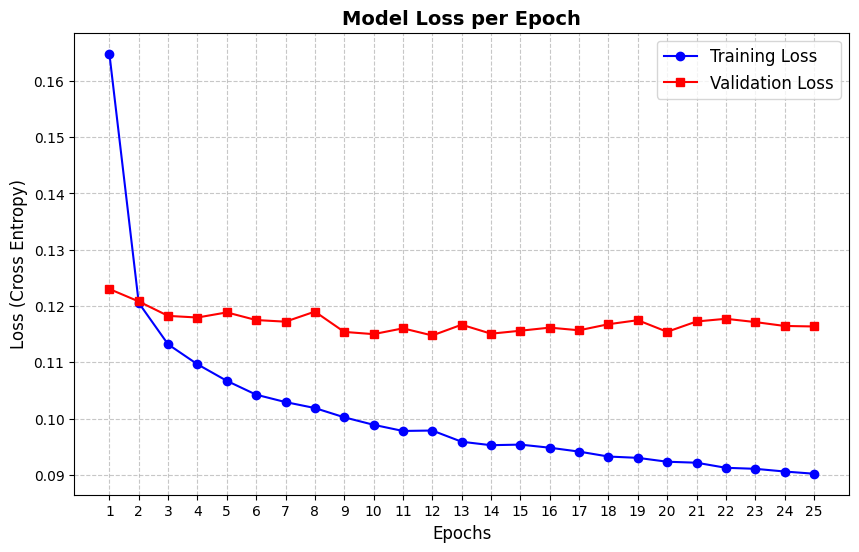

In [10]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='red', marker='s')

plt.title('Model Loss per Epoch', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Cross Entropy)', fontsize=12)
plt.xticks(epochs) # Ensure x-axis shows whole integer epochs
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the artifact for your reports
plt.savefig("../reports/figures/category_probe_loss_curve.png", bbox_inches='tight')
plt.show()

In [8]:
torch.save(model.state_dict(), "../models/fashion_classifier_fashionclip.pth")
print("Model saved to ../models/fashion_classifier_fashionclip.pth")

Model saved to ../models/fashion_classifier_fashionclip.pth
